In [31]:
# Importación de librerías necesarias
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

In [32]:
# Configuración que permite mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [33]:
# Lectura del dataset desde la base de datos
query = "SELECT * FROM hospital_performance_final"

df = pd.read_sql(query, engine)
df.head()

,hospital_id,hospital_name,sector,city,province,hospital_type,year,total_beds,icu_beds,operation_theatres,emergency_department,diagnostic_labs,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,insurance_accepted,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,ambulance_available,telemedicine_service,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi
0,H10000,Hospital_TSDGA,Public,Sialkot,Punjab,Specialized,2024,1432,49,6,Yes,No,5.3,331,120,799,269,0.001418,2367,775,260,3.2,692,976.0,621.0,39060.0,29429077.0,Yes,5.1,2.24,3.34,8.49,31,8.2,Yes,No,49.0,2392.833333,0,0.034218,0.138330,43.333333,1399.0,0.584663,0.342,0.826,0.990,0.617
1,H10001,Hospital_VAXQQ,Private,Quetta,Balochistan,General,2023,905,29,4,No,No,8.5,271,36,381,38,0.001547,642,1488,101,3.7,61,3614.0,2516.0,31821.0,0.0,Yes,7.3,0.66,6.70,7.76,5,29.1,No,Yes,15.0,691.600000,0,0.032044,0.391845,25.250000,690.0,0.997687,0.443,0.871,0.937,0.670
2,H10002,Hospital_XABQD,Public,Kasur,Punjab,Specialized,2024,456,141,20,Yes,Yes,6.8,135,90,83,212,0.000927,992,928,331,4.6,16,6865.0,252.0,45706.0,38516209.0,No,7.9,4.71,4.07,7.39,179,3.7,Yes,No,68.0,1022.933333,0,0.309211,0.131973,16.550000,430.0,0.420360,0.362,0.321,0.871,0.452
3,H10003,Hospital_AYNGM,Public,Sheikhupura,Punjab,Specialized,2023,890,121,1,No,Yes,7.5,216,101,115,253,0.001625,921,170,162,4.7,257,12006.0,276.0,75900.0,35923243.0,No,7.5,3.95,5.32,9.41,116,39.1,Yes,Yes,45.0,926.666667,0,0.135955,0.233094,162.000000,584.0,0.630216,0.278,0.495,0.767,0.441
4,H10004,Hospital_ZRAVI,Public,Sheikhupura,Punjab,Specialized,2022,978,72,17,Yes,Yes,7.4,381,43,474,65,0.000704,1555,591,283,7.7,690,875.0,530.0,73349.0,32512196.0,Yes,9.1,4.88,0.96,3.15,99,18.4,Yes,No,15.0,1574.700000,0,0.073620,0.241951,16.647059,920.0,0.584238,0.657,0.367,0.992,0.637


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   hospital_id                 5500 non-null   object 
 1   hospital_name               5500 non-null   object 
 2   sector                      5500 non-null   object 
 3   city                        5500 non-null   object 
 4   province                    5500 non-null   object 
 5   hospital_type               5500 non-null   object 
 6   year                        5500 non-null   int64  
 7   total_beds                  5500 non-null   int64  
 8   icu_beds                    5500 non-null   int64  
 9   operation_theatres          5500 non-null   int64  
 10  emergency_department        5500 non-null   object 
 11  diagnostic_labs             5500 non-null   object 
 12  medical_equipment_score     5500 non-null   float64
 13  total_doctors               5500 

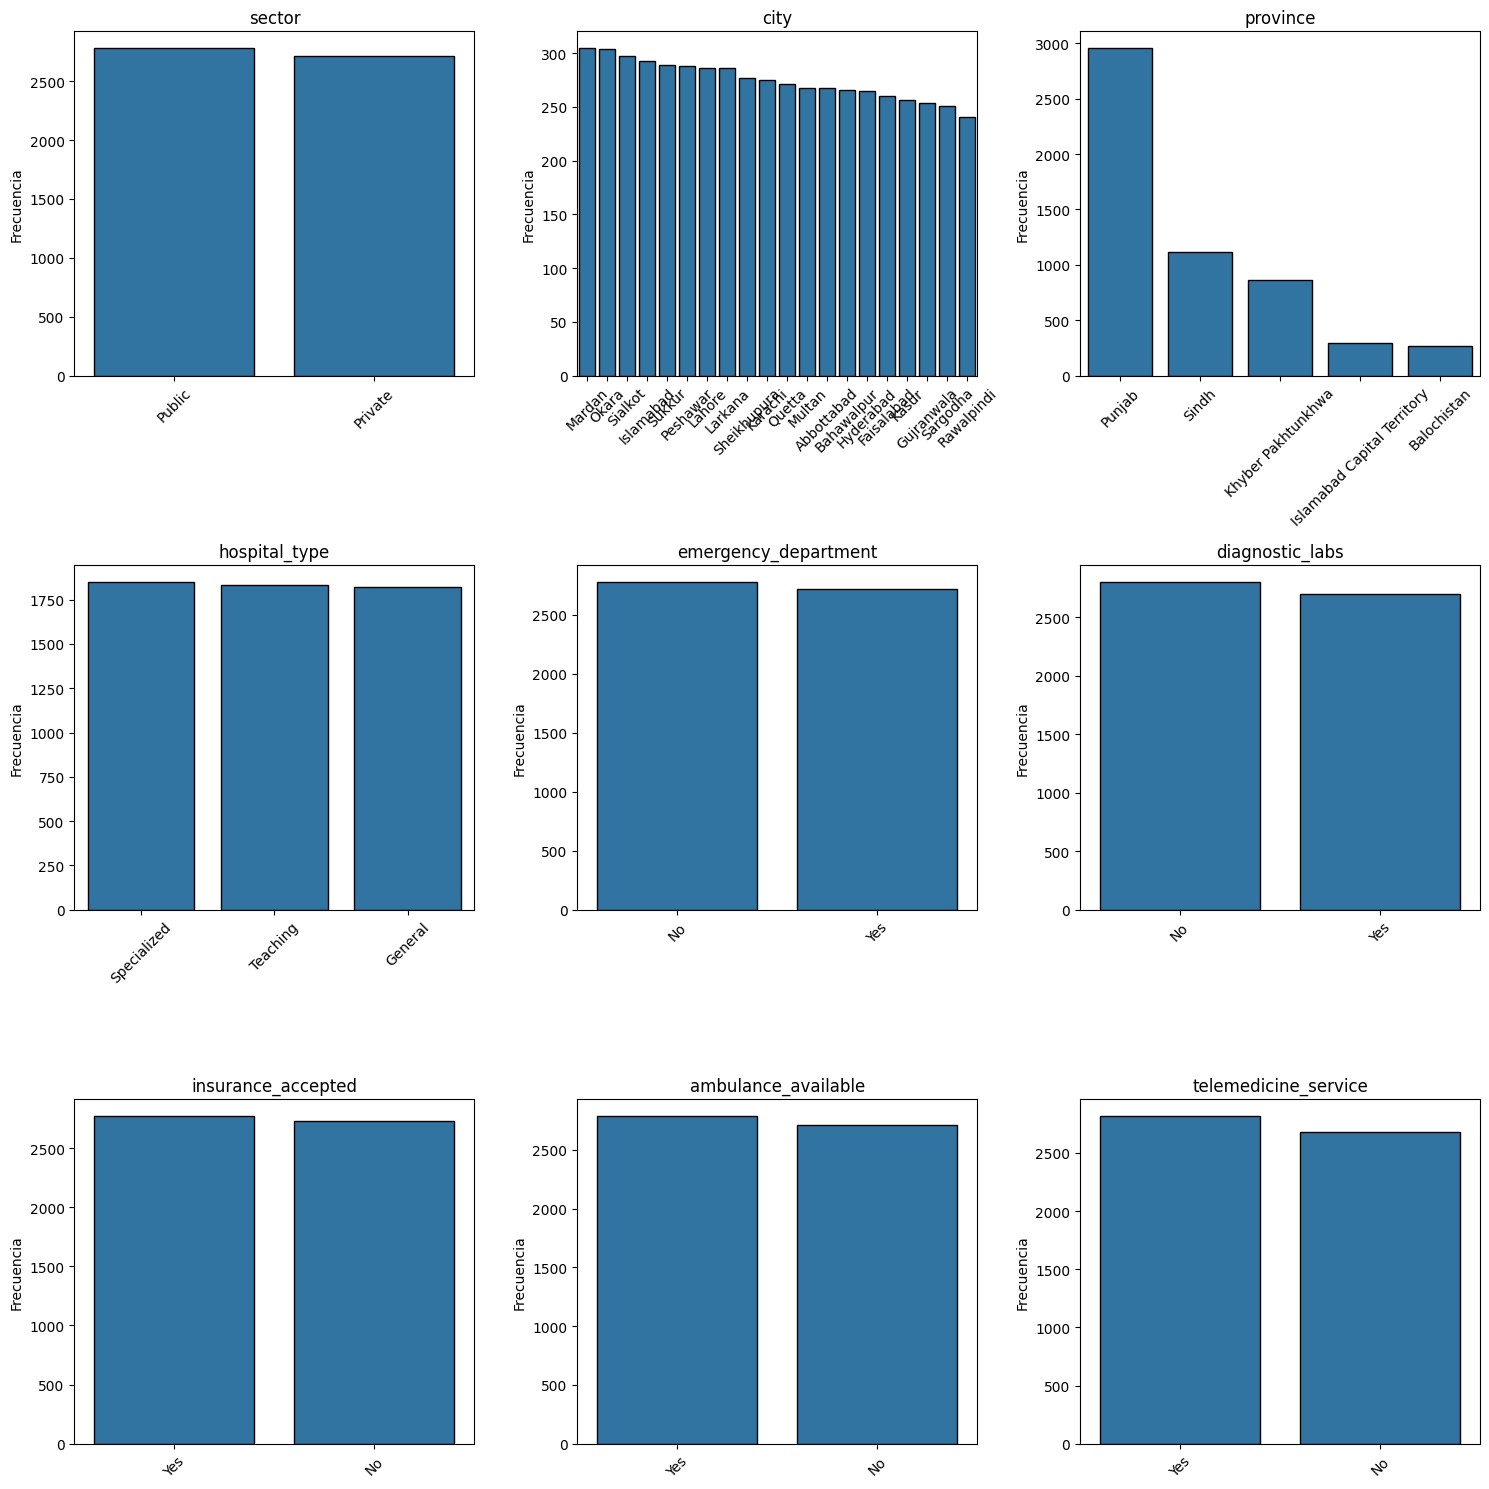

In [35]:
# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 30  # filtro recomendable
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # simplifica indexado

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    value_counts = df[col].value_counts()
    
    sns.barplot(x=value_counts.index, y=value_counts.values, edgecolor="black", ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

# eliminar ejes vacíos (si sobran)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

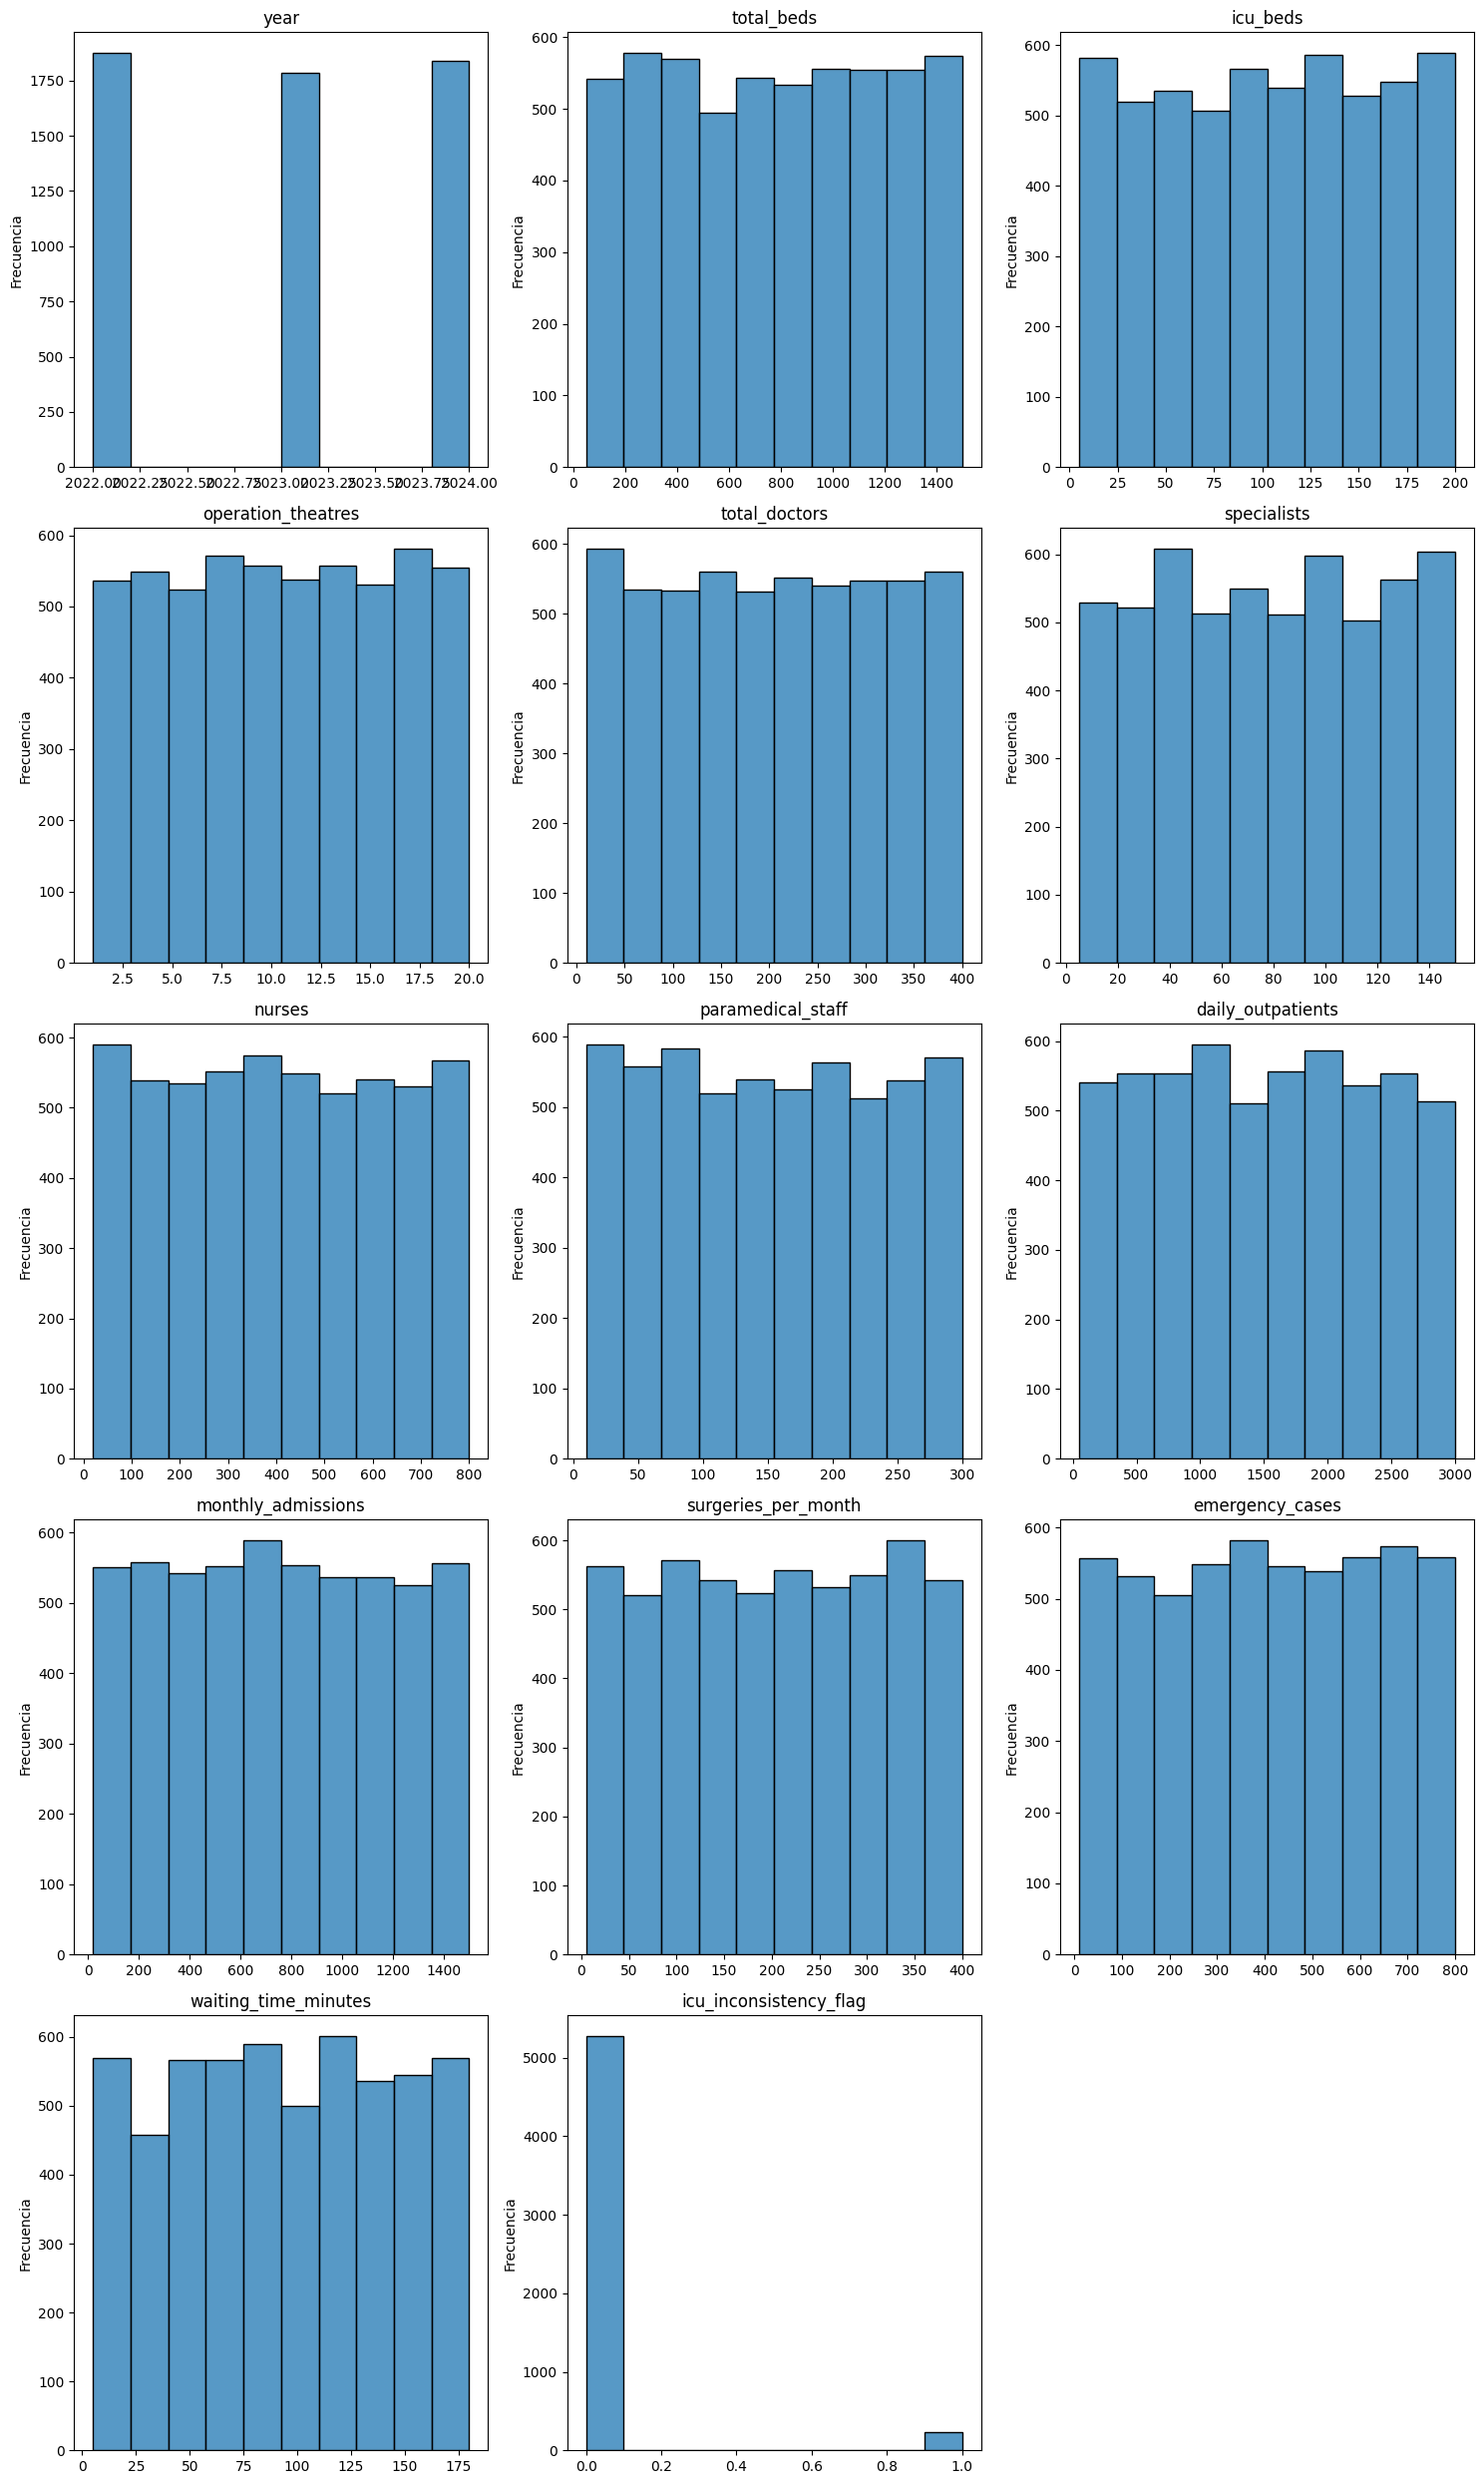

In [36]:
# seleccionar variables enteras
int_cols = df.select_dtypes(include=["int64", "int32"]).columns

n_cols = 3
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    data = df[col].dropna()
    
    sns.histplot(data, bins=10, edgecolor="black", ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

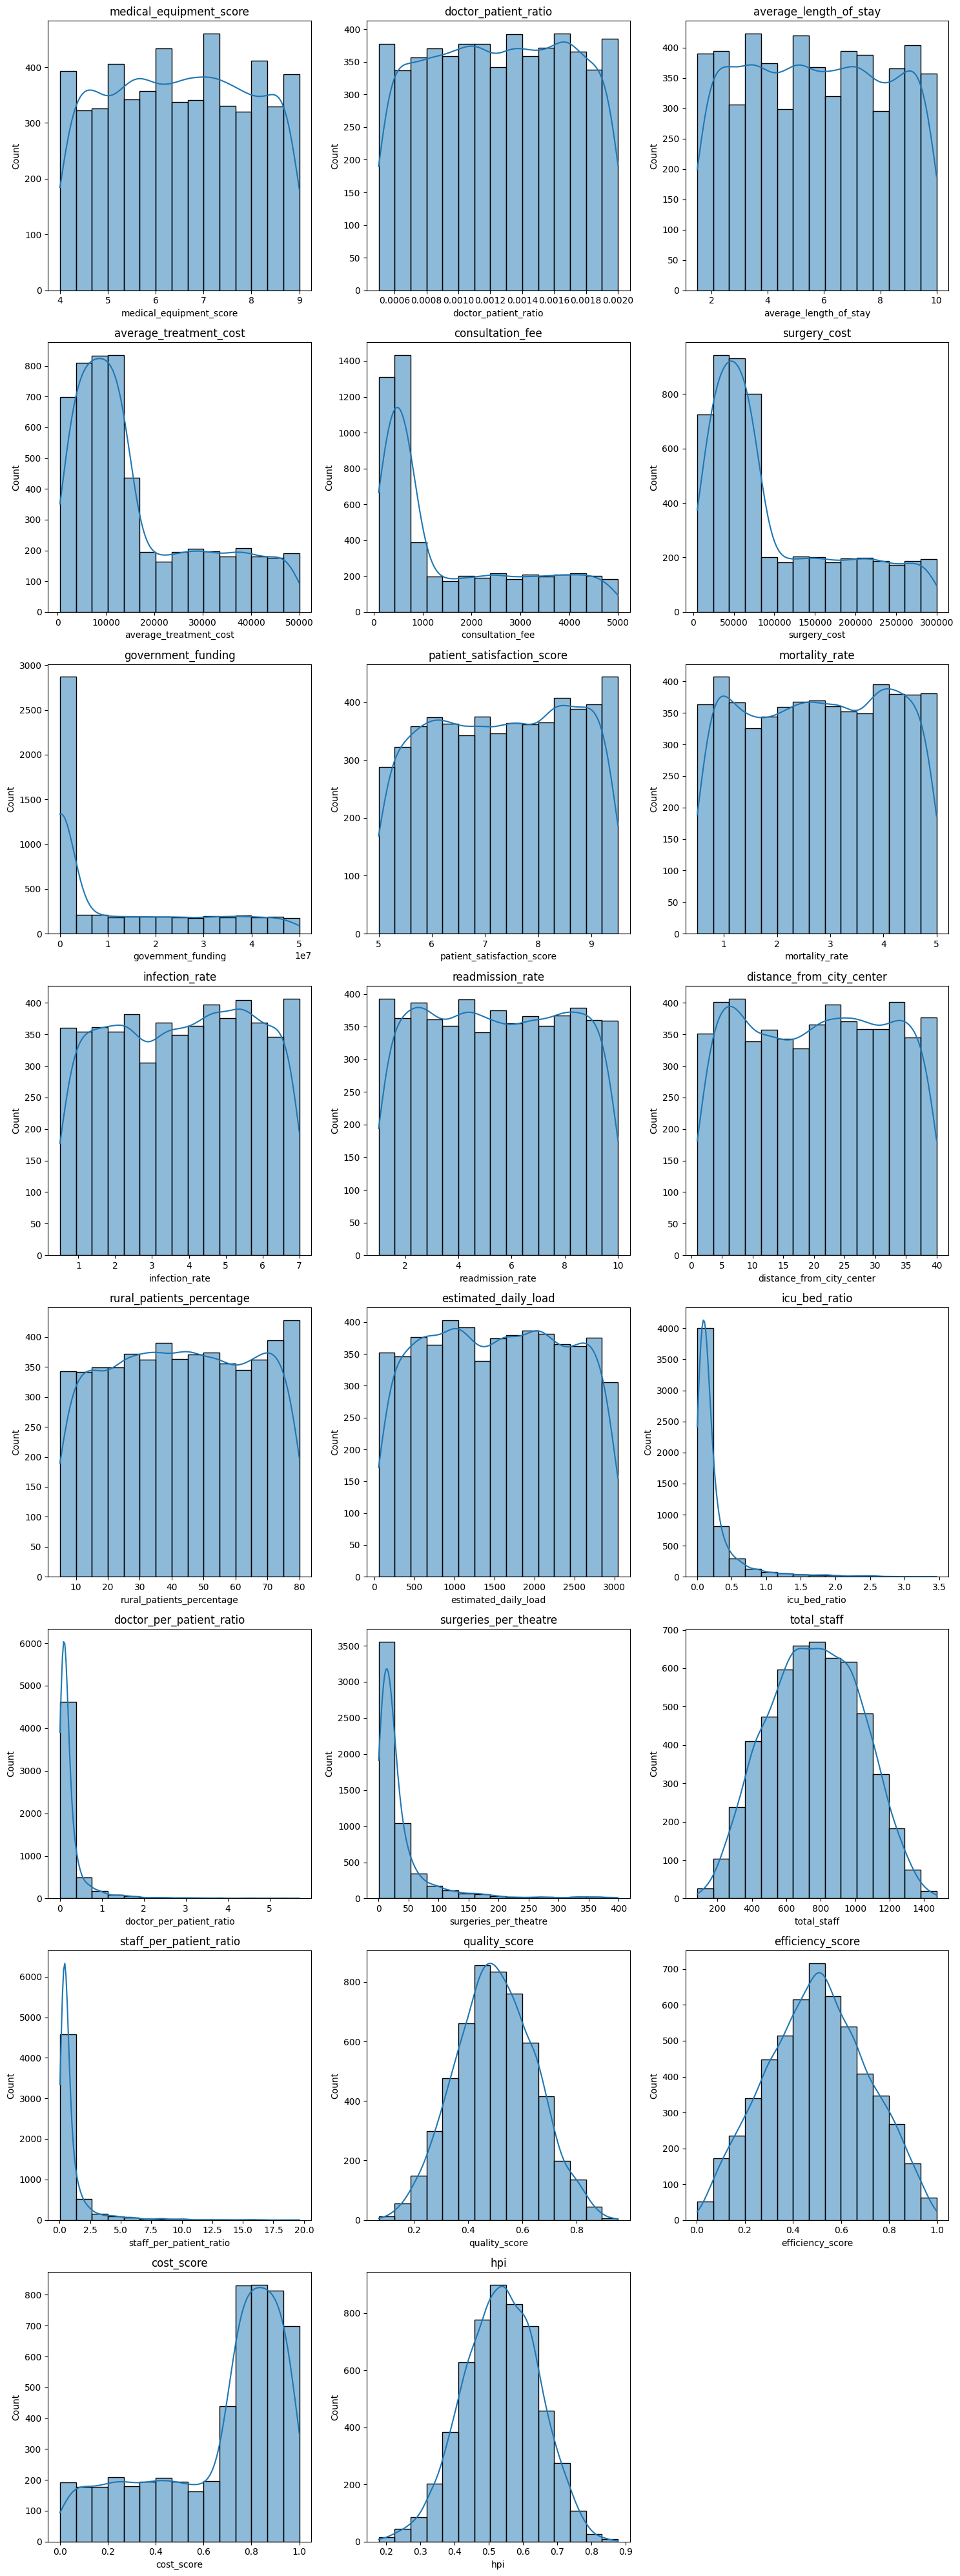

In [37]:
# seleccionar variables continuas (float)
float_cols = df.select_dtypes(include=["float64", "float32"]).columns

n_cols = 3  # ajustable
n_rows = math.ceil(len(float_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    ax = axes[i]
    
    data = df[col].dropna()

    sns.histplot(data, bins=15, edgecolor="black", kde=True, ax=ax)
    
    ax.set_title(col)

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()